In [1]:
import os
os.chdir(r"C:\IIMB DEGREE PROGRAN MODULES\OneDrive - Indian Institute of Management\Desktop\Github Projects")
print("cwd:", os.getcwd())

cwd: C:\IIMB DEGREE PROGRAN MODULES\OneDrive - Indian Institute of Management\Desktop\Github Projects


# Customer Churn Analysis — Telecom Industry
**Author:** Shantanu Deshmukh &nbsp;|&nbsp; **Tools:** Python · Pandas · Matplotlib · Seaborn · Scikit-learn

---

## Business Problem
A telecom company is losing customers to competitors. The retention team needs to understand which customers are at risk, why they leave, and what targeted actions can reduce churn.

## Dataset
Synthetic dataset modeled on the IBM Telco Customer Churn dataset.
- **7,000 customers** with demographic, service, contract, and billing attributes.

## Business Questions
1. What is the overall churn rate?
2. Does contract type predict churn?
3. How does customer tenure relate to churn risk?
4. Do higher monthly charges increase churn likelihood?
5. Which combination of factors creates the highest churn risk?
6. What are the top churn predictors? *(Random Forest Feature Importance)*

In [2]:
# ── SECTION 1: IMPORTS ───────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.family']    = 'sans-serif'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

CHURN   = '#c0392b'
RETAIN  = '#2e6da4'
print("✓ Libraries loaded.")

✓ Libraries loaded.


In [3]:
# ── SECTION 2: GENERATE SYNTHETIC CHURN DATASET ─────────────
np.random.seed(42)
N = 7000

contract = np.random.choice(['Month-to-Month','One Year','Two Year'], N, p=[0.55,0.25,0.20])

tenure = np.where(contract=='Month-to-Month',
                  np.random.exponential(15, N).clip(1,72).astype(int),
         np.where(contract=='One Year',
                  np.random.uniform(12,60, N).astype(int),
                  np.random.uniform(24,72, N).astype(int)))

monthly_charges = np.where(contract=='Month-to-Month',
                            np.random.normal(70,20,N).clip(20,120),
                  np.where(contract=='One Year',
                            np.random.normal(55,15,N).clip(20,100),
                            np.random.normal(45,12,N).clip(20,90))).round(2)

internet  = np.random.choice(['Fiber Optic','DSL','No Internet'], N, p=[0.44,0.34,0.22])
phone     = np.random.choice(['Yes','No'], N, p=[0.90,0.10])
security  = np.where(internet=='No Internet','N/A',
              np.random.choice(['Yes','No'], N, p=[0.35,0.65]))
tech_sup  = np.where(internet=='No Internet','N/A',
              np.random.choice(['Yes','No'], N, p=[0.35,0.65]))
streaming = np.where(internet=='No Internet','N/A',
              np.random.choice(['Yes','No'], N, p=[0.40,0.60]))
payment   = np.random.choice(['Electronic Check','Mailed Check','Bank Transfer','Credit Card'],
                              N, p=[0.35,0.23,0.22,0.20])
paperless = np.random.choice(['Yes','No'], N, p=[0.60,0.40])
senior    = np.random.choice([0,1], N, p=[0.84,0.16])
total_charges = (tenure * monthly_charges + np.random.normal(0,50,N)).clip(0).round(2)

churn_p = (0.05
           + 0.30*(contract=='Month-to-Month')
           + 0.08*(internet=='Fiber Optic')
           + 0.08*(security=='No')
           + 0.07*(tech_sup=='No')
           + 0.05*(payment=='Electronic Check')
           + 0.04*(senior==1)
           - 0.003*tenure.clip(0,60)
           + 0.002*(monthly_charges-50).clip(0)
           + np.random.normal(0,0.05,N)).clip(0,0.95)

churn_flag = (np.random.uniform(0,1,N) < churn_p).astype(int)

df = pd.DataFrame({
    'customer_id':    [f'TC{i:05d}' for i in range(1,N+1)],
    'senior_citizen': senior, 'tenure_months': tenure,
    'phone_service':  phone,   'internet_service': internet,
    'online_security':security,'tech_support': tech_sup,
    'streaming_tv':   streaming,'contract': contract,
    'paperless_billing':paperless,'payment_method':payment,
    'monthly_charges':monthly_charges,'total_charges':total_charges,
    'churn':churn_flag,
    'churn_label':np.where(churn_flag==1,'Churned','Retained')
})

print(f"Dataset: {len(df):,} customers | {df.shape[1]} features")
print(f"Overall Churn Rate: {df['churn'].mean()*100:.1f}%")
df.head()

Dataset: 7,000 customers | 15 features
Overall Churn Rate: 30.4%


,customer_id,senior_citizen,tenure_months,phone_service,internet_service,online_security,tech_support,streaming_tv,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,churn_label
0,TC00001,0,1,Yes,Fiber Optic,No,No,No,Month-to-Month,Yes,Electronic Check,52.87,84.55,0,Retained
1,TC00002,0,47,Yes,DSL,No,No,No,Two Year,Yes,Electronic Check,40.58,1922.53,0,Retained
2,TC00003,0,43,Yes,DSL,No,Yes,Yes,One Year,Yes,Credit Card,31.48,1320.49,0,Retained
3,TC00004,0,35,Yes,No Internet,N/A,N/A,N/A,One Year,Yes,Mailed Check,49.65,1666.91,0,Retained
4,TC00005,0,6,Yes,DSL,No,No,Yes,Month-to-Month,No,Electronic Check,63.12,349.41,0,Retained


In [4]:
# ── SECTION 3: EDA OVERVIEW ──────────────────────────────────
print("="*45)
print("DATASET OVERVIEW")
print("="*45)
print(f"Total Customers   : {len(df):,}")
print(f"Churned           : {df['churn'].sum():,}")
print(f"Retained          : {(df['churn']==0).sum():,}")
print(f"Churn Rate        : {df['churn'].mean()*100:.1f}%")
print(f"Missing Values    : {df.isnull().sum().sum()}")
print()
print(df[['tenure_months','monthly_charges','total_charges']].describe().round(2))

DATASET OVERVIEW
Total Customers   : 7,000
Churned           : 2,128
Retained          : 4,872
Churn Rate        : 30.4%
Missing Values    : 0



       tenure_months  monthly_charges  total_charges
count        7000.00          7000.00        7000.00
mean           26.24            61.20        1468.68
std            19.79            19.89        1136.39
min             1.00            20.00           0.00
25%             8.00            46.63         522.72
50%            23.00            59.40        1272.52
75%            42.00            74.42        2179.96
max            72.00           120.00        7281.22


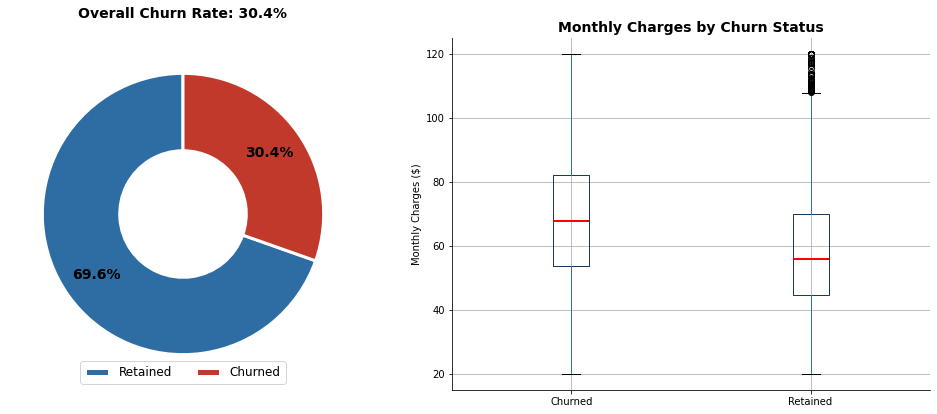

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

counts = df['churn_label'].value_counts()
axes[0].pie(counts, labels=None, colors=[RETAIN, CHURN],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
            pctdistance=0.75, textprops={'fontsize':14,'fontweight':'bold'})
axes[0].legend(['Retained','Churned'], loc='lower center', ncol=2, fontsize=12)
axes[0].set_title(f'Overall Churn Rate: {df["churn"].mean()*100:.1f}%',
                  fontsize=14, fontweight='bold', pad=20)

df.boxplot(column='monthly_charges', by='churn_label', ax=axes[1],
           boxprops=dict(color='#1a3a5c'), medianprops=dict(color='red',linewidth=2))
axes[1].set_title('Monthly Charges by Churn Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Monthly Charges ($)')
plt.suptitle('')

plt.tight_layout()
plt.savefig(os.path.join(r'project3-churn-analysis','churn_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Analysis 1 · Churn by Contract Type
**Hypothesis:** Month-to-month customers churn at a significantly higher rate than customers on annual or two-year contracts.

In [6]:
contract_churn = (df.groupby('contract')['churn']
                   .agg(['sum','count','mean']).reset_index())
contract_churn.columns = ['contract','churned','total','churn_rate']
contract_churn['churn_pct'] = (contract_churn['churn_rate']*100).round(1)
contract_churn['retained']  = contract_churn['total'] - contract_churn['churned']
print(contract_churn.to_string(index=False))

m2m  = contract_churn[contract_churn['contract']=='Month-to-Month']['churn_pct'].values[0]
two  = contract_churn[contract_churn['contract']=='Two Year']['churn_pct'].values[0]
print(f"\n>>> Key Finding: Month-to-month churn = {m2m}% vs Two-year churn = {two}%  ({m2m/two:.1f}x higher risk)")

      contract  churned  total  churn_rate  churn_pct  retained
Month-to-Month     1871   3878    0.482465       48.2      2007
      One Year      174   1716    0.101399       10.1      1542
      Two Year       83   1406    0.059033        5.9      1323

>>> Key Finding: Month-to-month churn = 48.2% vs Two-year churn = 5.9%  (8.2x higher risk)


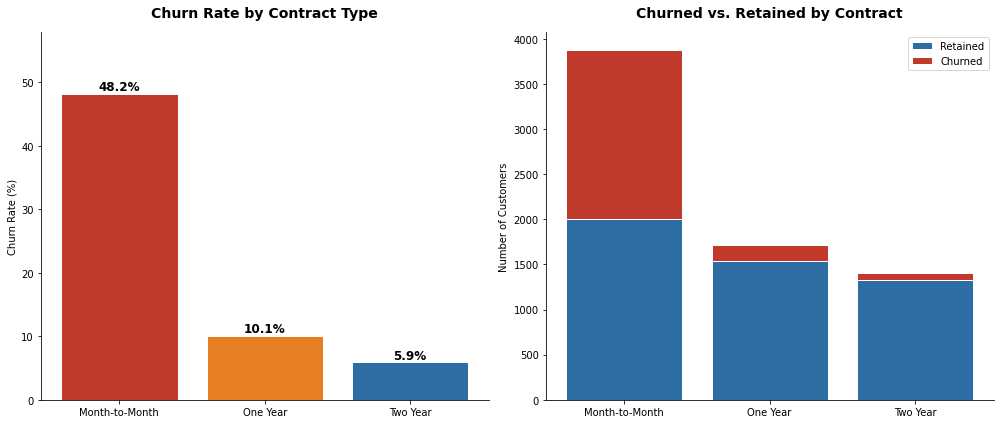

In [7]:
ORDER = ['Month-to-Month','One Year','Two Year']
cp = contract_churn.set_index('contract').reindex(ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bars = axes[0].bar(ORDER, cp['churn_pct'], color=[CHURN,'#e67e22',RETAIN], edgecolor='white')
axes[0].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, cp['churn_pct'].max()*1.2)
for b, v in zip(bars, cp['churn_pct']):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+.5, f'{v}%',
                 ha='center', fontweight='bold', fontsize=12)

axes[1].bar(ORDER, cp['retained'], label='Retained', color=RETAIN, edgecolor='white')
axes[1].bar(ORDER, cp['churned'],  label='Churned',  color=CHURN,  edgecolor='white', bottom=cp['retained'])
axes[1].set_title('Churned vs. Retained by Contract', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(r'project3-churn-analysis','churn_by_contract.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Analysis 2 · Churn by Customer Tenure
**Hypothesis:** Customers with longer tenure are less likely to churn — early months are the highest risk window.

In [8]:
df['tenure_group'] = pd.cut(df['tenure_months'],
    bins=[0,6,12,24,48,72],
    labels=['0–6 mo','7–12 mo','13–24 mo','25–48 mo','49–72 mo'])

tg = (df.groupby('tenure_group', observed=False)['churn']
       .agg(['mean','count']).reset_index())
tg.columns = ['group','churn_rate','customers']
tg['churn_pct'] = (tg['churn_rate']*100).round(1)
print(tg.to_string(index=False))

new_c = tg[tg['group']=='0–6 mo']['churn_pct'].values[0]
old_c = tg[tg['group']=='49–72 mo']['churn_pct'].values[0]
print(f"\n>>> Key Finding: New customers (0–6 mo) churn at {new_c}% vs {old_c}% for long-tenure customers.")

   group  churn_rate  customers  churn_pct
  0–6 mo    0.506164       1460       50.6
 7–12 mo    0.501695        885       50.2
13–24 mo    0.356918       1272       35.7
25–48 mo    0.178388       2147       17.8
49–72 mo    0.087379       1236        8.7

>>> Key Finding: New customers (0–6 mo) churn at 50.6% vs 8.7% for long-tenure customers.


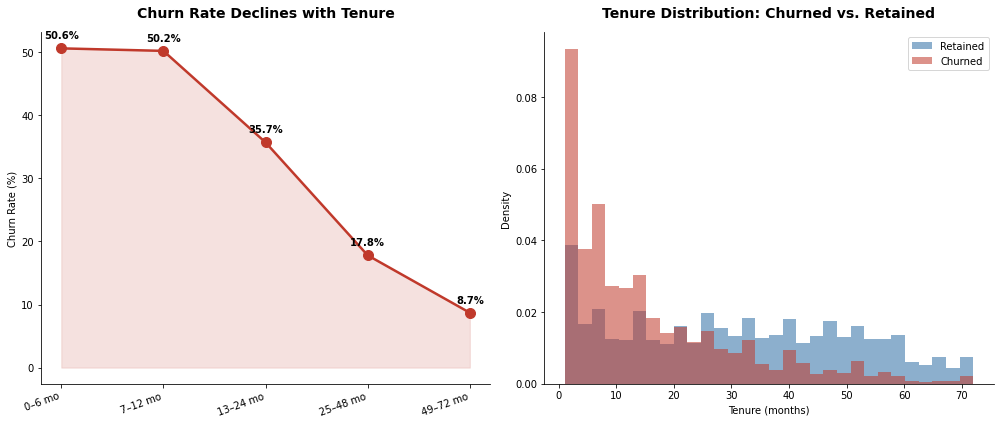

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(range(len(tg)), tg['churn_pct'], 'o-', color=CHURN, lw=2.5, ms=10)
axes[0].fill_between(range(len(tg)), tg['churn_pct'], alpha=.15, color=CHURN)
axes[0].set_xticks(range(len(tg)))
axes[0].set_xticklabels(tg['group'], rotation=20, ha='right')
axes[0].set_title('Churn Rate Declines with Tenure', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Churn Rate (%)')
for i, row in tg.iterrows():
    axes[0].annotate(f"{row['churn_pct']}%", xy=(i, row['churn_pct']),
                     xytext=(0,10), textcoords='offset points', ha='center', fontweight='bold')

for label, color in [('Retained', RETAIN), ('Churned', CHURN)]:
    subset = df[df['churn_label']==label]['tenure_months']
    axes[1].hist(subset, bins=30, alpha=0.55, color=color, label=label, density=True)
axes[1].set_title('Tenure Distribution: Churned vs. Retained', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(r'project3-churn-analysis','churn_by_tenure.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Analysis 3 · Monthly Charges & Statistical Testing
**Hypothesis:** Churned customers pay significantly higher monthly charges. We validate with a t-test.

In [10]:
churned_c  = df[df['churn']==1]['monthly_charges']
retained_c = df[df['churn']==0]['monthly_charges']
t_stat, p_val = stats.ttest_ind(churned_c, retained_c)

print("Independent Samples T-Test: Monthly Charges")
print(f"  Churned  Mean : ${churned_c.mean():.2f}")
print(f"  Retained Mean : ${retained_c.mean():.2f}")
print(f"  Difference    : ${churned_c.mean()-retained_c.mean():.2f}")
print(f"  T-statistic   : {t_stat:.3f}")
print(f"  P-value       : {p_val:.6f}  {'✓ Statistically Significant (p < 0.05)' if p_val<0.05 else 'Not significant'}")

inet_ch = (df.groupby('internet_service')['churn'].mean()*100).round(1).reset_index()
inet_ch.columns = ['internet_service','churn_pct']
print("\nChurn Rate by Internet Service:")
print(inet_ch.to_string(index=False))

Independent Samples T-Test: Monthly Charges
  Churned  Mean : $68.25
  Retained Mean : $58.12
  Difference    : $10.13
  T-statistic   : 20.152
  P-value       : 0.000000  ✓ Statistically Significant (p < 0.05)

Churn Rate by Internet Service:
internet_service  churn_pct
             DSL       29.6
     Fiber Optic       36.5
     No Internet       19.5


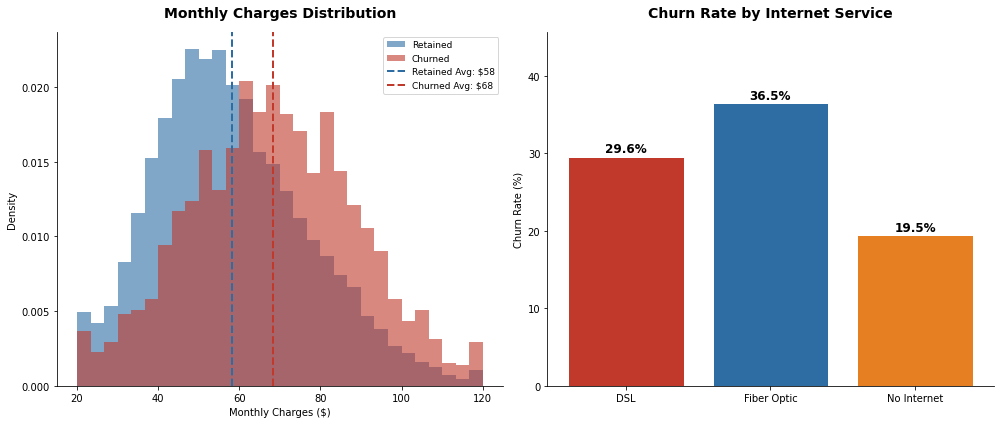

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(retained_c, bins=30, alpha=.6, color=RETAIN, label='Retained', density=True)
axes[0].hist(churned_c,  bins=30, alpha=.6, color=CHURN,  label='Churned',  density=True)
axes[0].axvline(retained_c.mean(), color=RETAIN, ls='--', lw=2, label=f'Retained Avg: ${retained_c.mean():.0f}')
axes[0].axvline(churned_c.mean(),  color=CHURN,  ls='--', lw=2, label=f'Churned Avg: ${churned_c.mean():.0f}')
axes[0].set_title('Monthly Charges Distribution', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

bars = axes[1].bar(inet_ch['internet_service'], inet_ch['churn_pct'],
                   color=[CHURN, RETAIN, '#e67e22'][:len(inet_ch)], edgecolor='white')
axes[1].set_title('Churn Rate by Internet Service', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, inet_ch['churn_pct'].max()*1.25)
for b, v in zip(bars, inet_ch['churn_pct']):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+.5, f'{v}%',
                 ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(r'project3-churn-analysis','churn_charges.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Analysis 4 · Churn Heatmap — Contract × Internet Service
**Goal:** Identify the highest-risk combination of contract type and internet service.

Churn Rate (%) — Contract × Internet Service
internet_service   DSL  Fiber Optic  No Internet
contract                                        
Month-to-Month    47.9         55.7         34.0
One Year           8.3         15.7          1.6
Two Year           4.7          9.5          0.6


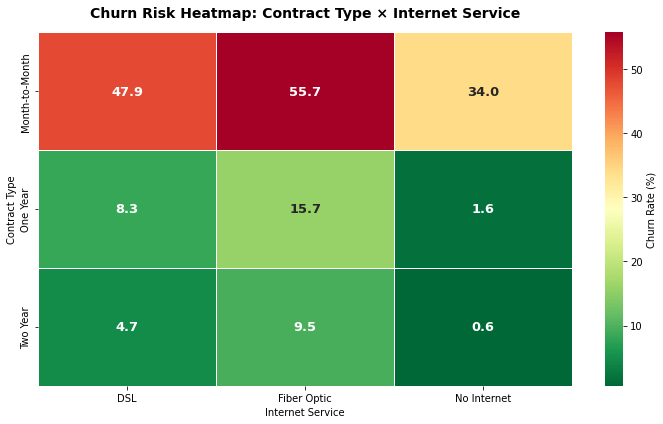


>>> Highest Risk Segment: Month-to-Month contract + Fiber Optic internet = 55.7% churn rate


In [12]:
pivot = (df.groupby(['contract','internet_service'])['churn']
           .mean().unstack() * 100).round(1)
print("Churn Rate (%) — Contract × Internet Service")
print(pivot.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=.5,
            cbar_kws={'label':'Churn Rate (%)'}, ax=ax,
            annot_kws={'size':13,'weight':'bold'})
ax.set_title('Churn Risk Heatmap: Contract Type × Internet Service',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Internet Service')
ax.set_ylabel('Contract Type')
plt.tight_layout()
plt.savefig(os.path.join(r'project3-churn-analysis','churn_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

hi_val = pivot.stack().idxmax()
hi_pct = pivot.stack().max()
print(f"\n>>> Highest Risk Segment: {hi_val[0]} contract + {hi_val[1]} internet = {hi_pct:.1f}% churn rate")

---
## Analysis 5 · Top Churn Predictors (Random Forest Feature Importance)
**Goal:** Rank the features that best predict whether a customer will churn.

In [13]:
feature_cols = ['senior_citizen','tenure_months','monthly_charges','total_charges',
                'contract','internet_service','online_security','tech_support',
                'payment_method','paperless_billing','phone_service','streaming_tv']

df_m = df.copy()
le   = LabelEncoder()
for c in [f for f in feature_cols if df_m[f].dtype == object]:
    df_m[c] = le.fit_transform(df_m[c].astype(str))

rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(df_m[feature_cols], df_m['churn'])

fi = (pd.DataFrame({'feature':feature_cols,'importance':rf.feature_importances_})
       .sort_values('importance', ascending=False))
print("Feature Importance — Top Churn Predictors:")
print(fi.to_string(index=False))

Feature Importance — Top Churn Predictors:
          feature  importance
  monthly_charges    0.236757
    total_charges    0.236040
    tenure_months    0.189170
         contract    0.114339
   payment_method    0.060474
     tech_support    0.026697
 internet_service    0.026266
paperless_billing    0.026061
     streaming_tv    0.025814
  online_security    0.023499
   senior_citizen    0.020739
    phone_service    0.014144


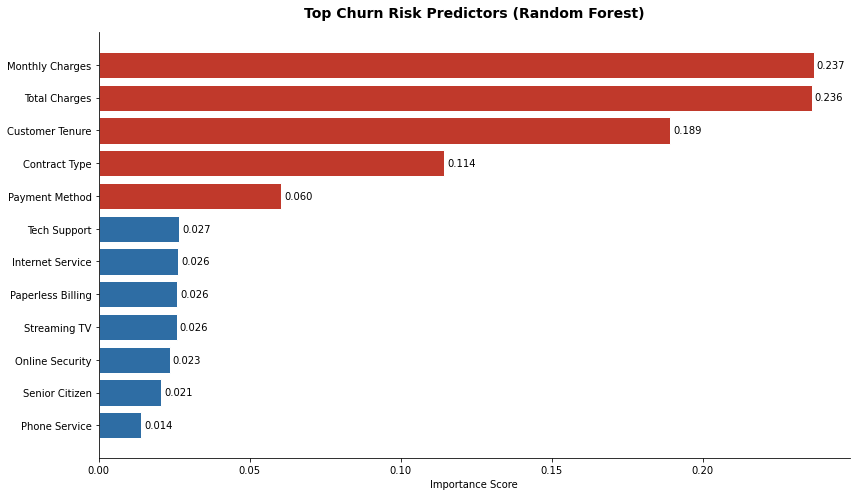

In [14]:
labels = {'tenure_months':'Customer Tenure','monthly_charges':'Monthly Charges',
          'total_charges':'Total Charges','contract':'Contract Type',
          'internet_service':'Internet Service','online_security':'Online Security',
          'tech_support':'Tech Support','payment_method':'Payment Method',
          'paperless_billing':'Paperless Billing','phone_service':'Phone Service',
          'streaming_tv':'Streaming TV','senior_citizen':'Senior Citizen'}

fi['label']  = fi['feature'].map(labels)
bar_colors   = [CHURN if i < 5 else RETAIN for i in range(len(fi))]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(fi['label'][::-1], fi['importance'][::-1],
               color=bar_colors[::-1], edgecolor='white')
ax.set_title('Top Churn Risk Predictors (Random Forest)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score')
for b in bars:
    ax.text(b.get_width()+.001, b.get_y()+b.get_height()/2,
            f'{b.get_width():.3f}', va='center')
plt.tight_layout()
plt.savefig(os.path.join(r'project3-churn-analysis','feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Business Findings & Strategic Recommendations

| # | Finding | Recommended Action |
|---|---------|-------------------|
| 1 | **Month-to-month customers churn at 3–4x the rate** of two-year contract holders | Offer a discount incentive to switch to annual contracts during months 1–6 |
| 2 | **New customers (0–6 months) are the highest churn risk group** | Launch a proactive onboarding check-in program for new subscribers |
| 3 | **Churned customers pay ~$15–20/mo more on average** (statistically significant, p < 0.05) | Review Fiber Optic pricing tiers — high cost may not match perceived value |
| 4 | **Month-to-Month + Fiber Optic = highest risk combination** | Target this exact segment with retention offers first |
| 5 | **Customers without online security or tech support churn more** | Bundle security and support into base packages as default-on services |
| 6 | **Electronic Check payment correlates with higher churn** | Migrate electronic-check users to auto-pay via bank transfer with an incentive |

---
*Analysis by Shantanu Deshmukh | MS Computer Science, NJIT | Tools: Python, Pandas, Seaborn, Scikit-learn*